In [1]:
# Install required packages
%pip install diffusers transformers accelerate torch torchvision torchaudio


In [2]:
import torch
from diffusers import StableDiffusionXLPipeline

# Load the stable diffusion XL base 1.0 model
pipe = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0", 
    torch_dtype=torch.float16, 
    variant="fp16", 
    use_safetensors=True
)

# Move to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
pipe.to(device)

print(f"Model loaded on {device}")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Model loaded on cuda


Token indices sequence length is longer than the specified maximum sequence length for this model (164 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['0." the screen flashes red with an " error " message. she looks around the room as the smoke gets thicker and darker, looking trapped and scared. [ part 3 ] sudden transition to a bright, safe, clear living room. the girl is now calm and wearing a heroic cape. she looks directly at the camera with a big, satisfied smile and gives a confident thumbs up. high - quality lighting, expressive character animation, 4 k.']
Token indices sequence length is longer than the specified maximum sequence length for this model (164 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['0." the s

Generating image with prompt: 'Animated 3D cinematic style. [PART 1] A young Asian girl in a living room filled with hazy smoke. She picks up a glowing smartphone with trembling hands. Close-up on the keypad; her finger hovers over the screen with a confused, anxious expression. [PART 2] She taps a wrong sequence like "999" or "000." The screen flashes red with an "Error" message. She looks around the room as the smoke gets thicker and darker, looking trapped and scared. [PART 3] Sudden transition to a bright, safe, clear living room. The girl is now calm and wearing a heroic cape. She looks directly at the camera with a big, satisfied smile and gives a confident thumbs up. High-quality lighting, expressive character animation, 4k.'


  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


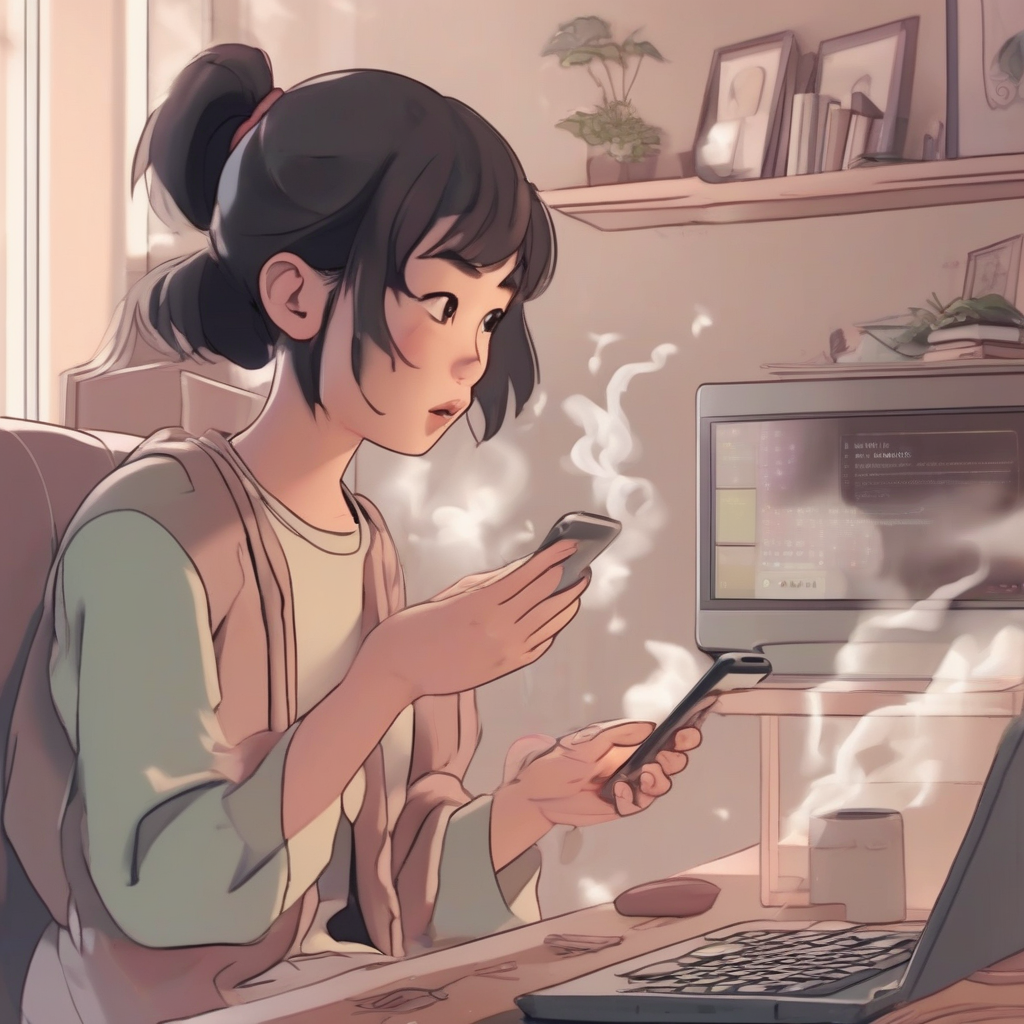

In [5]:
# Generate an image programmatically
from copy import Error


prompt = 'Animated 3D cinematic style. [PART 1] A young Asian girl in a living room filled with hazy smoke. She picks up a glowing smartphone with trembling hands. Close-up on the keypad; her finger hovers over the screen with a confused, anxious expression. [PART 2] She taps a wrong sequence like "999" or "000." The screen flashes red with an "Error" message. She looks around the room as the smoke gets thicker and darker, looking trapped and scared. [PART 3] Sudden transition to a bright, safe, clear living room. The girl is now calm and wearing a heroic cape. She looks directly at the camera with a big, satisfied smile and gives a confident thumbs up. High-quality lighting, expressive character animation, 4k.'
negative_prompt = ""    

print(f"Generating image with prompt: '{prompt}'")
image = pipe(prompt=prompt, negative_prompt=negative_prompt, num_inference_steps=25).images[0]

# Display the image
image

In [6]:
!pip install optimum-quanto

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 22.3 MB/s eta 0:00:00


In [9]:
import torch
from diffusers import StableDiffusionXLPipeline

# wangkanai/sdxl-fp8 is a popular repo hosting FP8 SDXL weights
pipe = StableDiffusionXLPipeline.from_single_file(
    "https://huggingface.co/wangkanai/sdxl-fp8/blob/main/checkpoints/sdxl/sdxl-base.safetensors",
    torch_dtype=torch.float16, # Keep pipeline execution in fp16
)
pipe.to("cuda")

checkpoints/sdxl/sdxl-base.safetensors:   0%|          | 0.00/6.94G [00:00<?, ?B/s]

Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

StableDiffusionXLPipeline {
  "_class_name": "StableDiffusionXLPipeline",
  "_diffusers_version": "0.37.0",
  "feature_extractor": [
    null,
    null
  ],
  "force_zeros_for_empty_prompt": true,
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "EulerDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "text_encoder_2": [
    "transformers",
    "CLIPTextModelWithProjection"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

Token indices sequence length is longer than the specified maximum sequence length for this model (164 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['0." the screen flashes red with an " error " message. she looks around the room as the smoke gets thicker and darker, looking trapped and scared. [ part 3 ] sudden transition to a bright, safe, clear living room. the girl is now calm and wearing a heroic cape. she looks directly at the camera with a big, satisfied smile and gives a confident thumbs up. high - quality lighting, expressive character animation, 4 k.']
Token indices sequence length is longer than the specified maximum sequence length for this model (164 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['0." the s

Generating image with prompt: 'Animated 3D cinematic style. [PART 1] A young Asian girl in a living room filled with hazy smoke. She picks up a glowing smartphone with trembling hands. Close-up on the keypad; her finger hovers over the screen with a confused, anxious expression. [PART 2] She taps a wrong sequence like "999" or "000." The screen flashes red with an "Error" message. She looks around the room as the smoke gets thicker and darker, looking trapped and scared. [PART 3] Sudden transition to a bright, safe, clear living room. The girl is now calm and wearing a heroic cape. She looks directly at the camera with a big, satisfied smile and gives a confident thumbs up. High-quality lighting, expressive character animation, 4k.'


  0%|          | 0/25 [00:00<?, ?it/s]

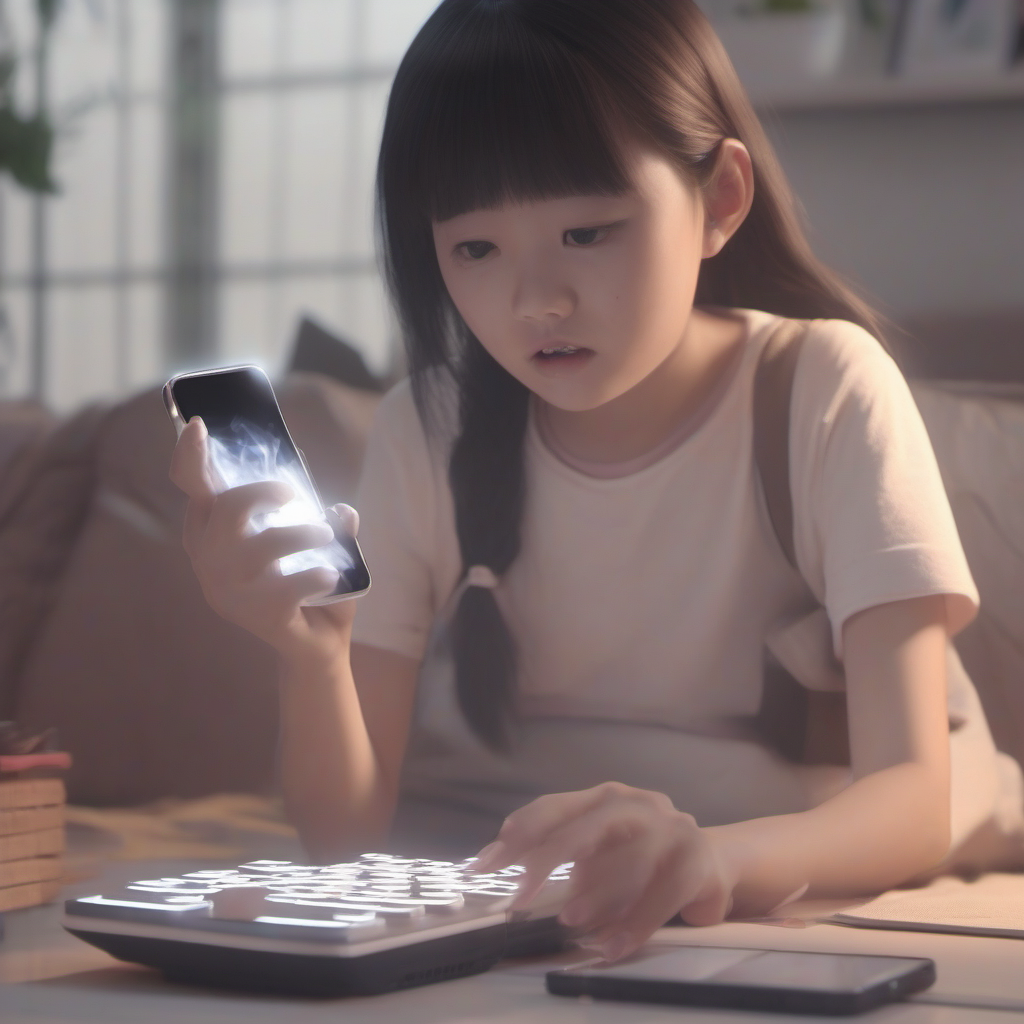

In [10]:
# Generate an image programmatically
from copy import Error


prompt = 'Animated 3D cinematic style. [PART 1] A young Asian girl in a living room filled with hazy smoke. She picks up a glowing smartphone with trembling hands. Close-up on the keypad; her finger hovers over the screen with a confused, anxious expression. [PART 2] She taps a wrong sequence like "999" or "000." The screen flashes red with an "Error" message. She looks around the room as the smoke gets thicker and darker, looking trapped and scared. [PART 3] Sudden transition to a bright, safe, clear living room. The girl is now calm and wearing a heroic cape. She looks directly at the camera with a big, satisfied smile and gives a confident thumbs up. High-quality lighting, expressive character animation, 4k.'
negative_prompt = ""    

print(f"Generating image with prompt: '{prompt}'")
image = pipe(prompt=prompt, negative_prompt=negative_prompt, num_inference_steps=25).images[0]

# Display the image
image

In [ ]:
from pyngrok import ngrok

# Authenticate ngrok (you need a free authtoken from their website)
ngrok.set_auth_token("2jgskLRiOe7GhBcW8GY1KA7rck6_2paMPJxXTQDagpfnfjdDd")

# Expose the port your image UI is running on (e.g., 7860 for Gradio)
public_url = ngrok.connect(7860)
print(f"Your image generator is live at: {public_url}")